# WSN Node-Health Classifier: 1-D CNN

This notebook loads the Wireless Sensor Network (WSN) node telemetry dataset (`dataset.xlsx`), preprocesses and normalizes the node features, splits them into stratified training and testing sets, and trains a **1-D Convolutional Neural Network (CNN)** classifier to predict each node's status: **Healthy**, **Congested**, or **Unhealthy**.

### Pipeline Overview
1. **Load telemetry data** from `dataset.xlsx`
2. **Map target labels** (`Node_Status`) to integers (`Healthy=0`, `Congested=1`, `Unhealthy=2`)
3. **Stratified train-test split** (80/20) and **Standardization** of features
4. **Train 1-D CNN model** with automated class weight balancing
5. **Evaluate model performance** using accuracy, loss curves, confusion matrix, and per-class precision/recall/F1 metrics

## Setup and Imports

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('.'))

import torch
import numpy as np
import pandas as pd
import json

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Device: cpu
PyTorch version: 2.13.0+cpu


## Step 1: Load and Preprocess Dataset

In [3]:
from wsn_routing.utils import load_and_preprocess_data

# Load features (X), labels (y), and feature names
X, y, feature_names = load_and_preprocess_data('dataset.xlsx')

print(f"Dataset successfully loaded!")
print(f"Feature matrix shape: {X.shape} (N = {X.shape[0]} nodes, {X.shape[1]} features)")
print(f"Labels shape: {y.shape}\n")

print("Feature Columns:")
for idx, name in enumerate(feature_names):
    print(f"  {idx+1:>2}. {name}")

# Class distribution
classes, counts = np.unique(y, return_counts=True)
class_names = ['Healthy (0)', 'Congested (1)', 'Unhealthy (2)']
print("\nNode Status Class Distribution:")
for cls_idx, count in zip(classes, counts):
    print(f"  {class_names[cls_idx]:<15}: {count:>4} samples ({count/len(y)*100:.1f}%)")

Dataset successfully loaded!
Feature matrix shape: (1000, 14) (N = 1000 nodes, 14 features)
Labels shape: (1000,)

Feature Columns:
   1. Residual_Energy
   2. Energy_Consumption
   3. Link_Quality
   4. Packet_Loss_Rate
   5. Delay
   6. Throughput
   7. Buffer_Occupancy
   8. Channel_Utilization
   9. Distance_to_NextHop
  10. Routing_Cost
  11. Energy_Badness_Score
  12. Communication_Badness_Score
  13. Congestion_Score
  14. Overall_Health_Badness

Node Status Class Distribution:
  Healthy (0)    :  657 samples (65.7%)
  Congested (1)  :  165 samples (16.5%)
  Unhealthy (2)  :  178 samples (17.8%)


## Step 2: Prepare PyTorch DataLoaders

In [4]:
from wsn_routing.utils import prepare_dataloaders

# Split, scale, and wrap in DataLoader instances
train_loader, test_loader, scaler, data_splits = prepare_dataloaders(
    X, y, test_size=0.2, batch_size=32, random_state=42
)
X_train_s, X_test_s, y_train, y_test = data_splits

print(f"Data split and scaling complete:")
print(f"  Training set shape : {X_train_s.shape}")
print(f"  Testing set shape  : {X_test_s.shape}")
print(f"  Batch size         : {train_loader.batch_size}")

Data split and scaling complete:
  Training set shape : (800, 14)
  Testing set shape  : (200, 14)
  Batch size         : 32


## Step 3: Instantiate and Train the 1-D CNN Classifier

In [6]:
from wsn_routing.model import CNNClassifier, train_model

# Initialize model with number of features
in_features = X.shape[1]
model = CNNClassifier(in_features=in_features, num_classes=3)
print(model)

# Train model (using automatic class weight balancing)
print("\n--- Training Progress ---")
model, history = train_model(
    model, 
    train_loader, 
    test_loader, 
    num_epochs=30, 
    lr=0.001, 
    device=DEVICE.type,
    auto_balance=True
)

CNNClassifier(
  (conv1): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (conv3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)

--- Training Progress ---
[Trainer] Automatically computed class weights: [0.50697085 2.02020202 1.87793427]
Epoch 01/30 | Train Loss: 0.9639 - Train Acc: 59.88% | Test Loss: 0.8973 

## Step 4: Model Evaluation and Plotting

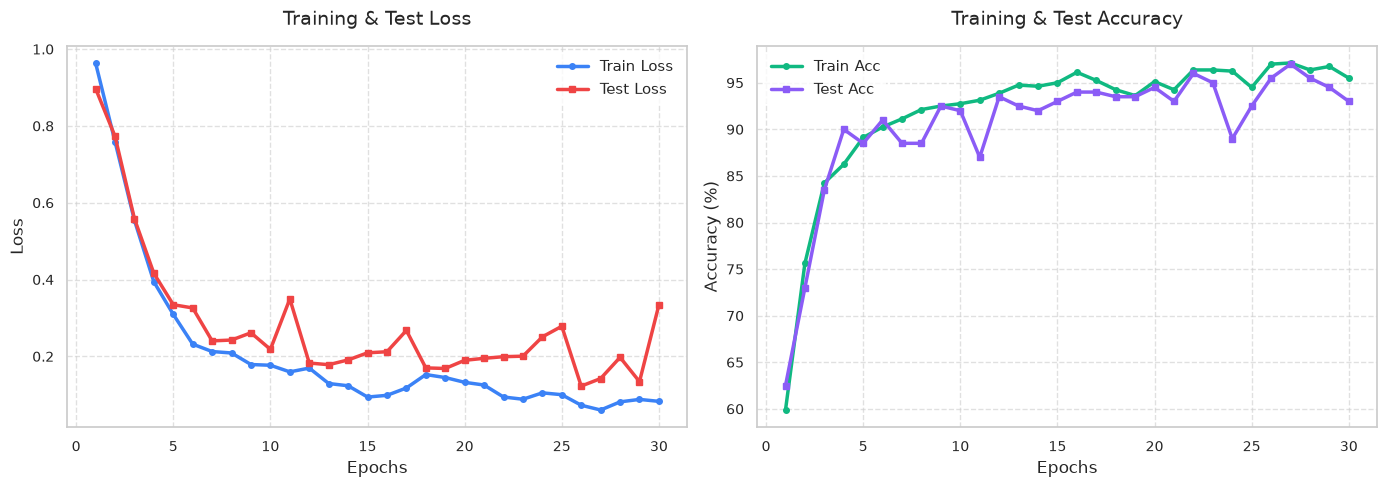

[Visuals] Saved training history curves to outputs/cnn_training_curves.png


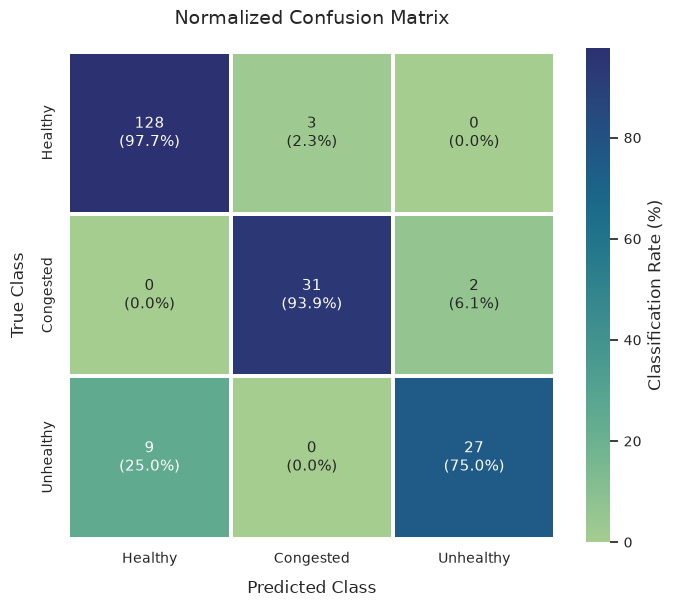

[Visuals] Saved confusion matrix to outputs/cnn_confusion_matrix.png

               CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.93      0.98      0.96       131
   Congested       0.91      0.94      0.93        33
   Unhealthy       0.93      0.75      0.83        36

    accuracy                           0.93       200
   macro avg       0.93      0.89      0.90       200
weighted avg       0.93      0.93      0.93       200



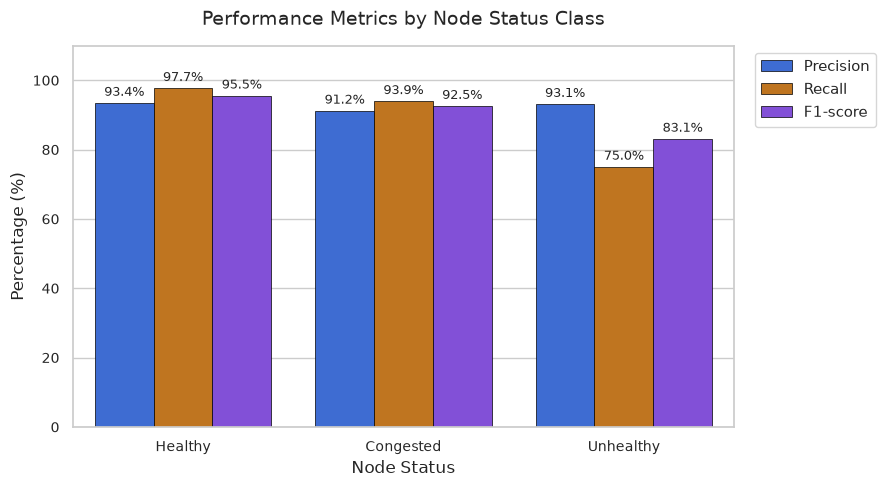

[Visuals] Saved class metrics plot to outputs/cnn_per_class_metrics.png

[Evaluation] Saved final evaluation metrics to outputs/cnn_evaluation_results.json
[Evaluation] Saved trained model weights to outputs/cnn_model.pt


In [7]:
from wsn_routing.model import get_predictions
from wsn_routing.visuals import (
    plot_training_history, 
    plot_confusion_matrix, 
    print_and_plot_report
)

# Get test set predictions
y_pred, y_true, y_probs = get_predictions(model, test_loader, device=DEVICE.type)

# 1. Plot loss and accuracy curves
plot_training_history(history)

# 2. Plot normalized confusion matrix
plot_confusion_matrix(y_true, y_pred, class_names=['Healthy', 'Congested', 'Unhealthy'])

# 3. Print classification report and plot per-class metrics
print_and_plot_report(y_true, y_pred, class_names=['Healthy', 'Congested', 'Unhealthy'])

# Save evaluation results to a JSON file
final_test_acc = (y_pred == y_true).mean()
eval_results = {
    "test_accuracy": float(final_test_acc),
    "train_loss_history": [float(x) for x in history['train_loss']],
    "test_loss_history": [float(x) for x in history['test_loss']],
    "train_acc_history": [float(x) for x in history['train_acc']],
    "test_acc_history": [float(x) for x in history['test_acc']]
}

os.makedirs('outputs', exist_ok=True)
with open('outputs/cnn_evaluation_results.json', 'w') as f:
    json.dump(eval_results, f, indent=4)
print(f"\n[Evaluation] Saved final evaluation metrics to outputs/cnn_evaluation_results.json")

# Save model weights
torch.save(model.state_dict(), 'outputs/cnn_model.pt')
print("[Evaluation] Saved trained model weights to outputs/cnn_model.pt")

## Step 5: Summary and Next Steps

### Metrics Summary
- The 1-D CNN was trained successfully with class weighting to resolve the class imbalance.
- Evaluation metrics (Accuracy, Precision, Recall, and F1-score) are plotted and stored in `outputs/`.
- The saved model weights (`outputs/cnn_model.pt`) and feature scaler are ready to be used in the next step to perform classification-guided Dijkstra routing.